# Indicator vs Monthly Return Testing

This notebook loads a JSON file containing indicator values and a monthly return variable, then automatically generates scatter plots of each indicator vs the monthly return.

In [18]:
import json
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import sklearn
import warnings
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import cross_val_score
# For ARIMA model
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
# For ADF test (Augmented Dickey-Fuller)
from statsmodels.tsa.stattools import adfuller
# For ACF and PACF plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
import os
print(os.getcwd())


c:\Users\20231351\Documents\HTT


In [3]:
Path.cwd().parent

WindowsPath('c:/Users/20231351/Documents')

In [4]:
path = Path.cwd().parent / "HTT" / "analysis_output" / "clean_dataset.csv"
jdf = pd.read_csv(path)
jdf

,Ticker,Date,BOED,OCF/BOED,ROA,CostExpenses/BOED,Stock/Oil ZScore,PGR,Monthly Return
0,NFG,2025-12-31,53051.0,5182.202032,1.973143,7075.908088,2.825966,11.730000,8.880840
1,COP,2025-12-31,224000.0,88375.000000,6.550816,29205.357143,1.994985,21.739130,16.205524
2,FANG,2025-12-31,497156.0,17616.200951,2.341716,27677.429217,2.364790,53.530000,12.146607
3,DVN,2025-12-31,389000.0,17251.928021,8.361024,7275.064267,1.153904,-0.410000,20.229319
4,EXE,2025-12-31,16164.0,283036.377134,6.430516,597191.289285,2.376671,90.672727,-6.895615
...,...,...,...,...,...,...,...,...,...
765,CKX,1998-12-31,100000.0,4.419620,8.743000,2.191770,-0.371745,0.000000,-4.316563
766,CKX,1998-09-30,21176000.0,0.020871,8.743000,0.010350,-0.371745,829.587357,-4.316563
767,MXC,1998-03-31,104401.0,11.141186,0.976244,29.401519,-0.713093,0.000000,1.960771
768,CKX,1998-03-31,17610000.0,0.025097,8.743000,0.012446,-0.371745,674.070000,-4.316563


In [5]:
path = Path.cwd().parent / "HTT" / "oil_industry_data.json"
jdf = pd.read_json(path)
jdf

,XOM,CVX,SHEL,TTE,PBR,PBR.A,BP,EQNR,E,SU,...,CRT,PVL,PRT,USEG,MXC,CKX,EONR,BRN,MTR,TPET
2025-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN
2025-09-30,NaN,"{'BOED': 6609000, 'OCF/BOED': 3502.79921319412...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,"{'BOED': 1000000, 'OCF/BOED': 0.336296, 'ROA':...",NaN,NaN,NaN,NaN
2025-06-30,NaN,"{'BOED': 3346500, 'OCF/BOED': 4113.25265202450...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,"{'BOED': 150000, 'OCF/BOED': 0.626840000000000...",NaN,NaN,NaN,NaN
2024-12-31,NaN,"{'BOED': 3338000, 'OCF/BOED': 9434.39185140802...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'BOED': 225.33, 'OCF/BOED': 13052.47858696134...","{'BOED': 22061.19, 'OCF/BOED': 9.2815029470305...",NaN,NaN,NaN,NaN
2025-03-31,NaN,"{'BOED': 13412000, 'OCF/BOED': 386.89233522218...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,"{'BOED': 100000, 'OCF/BOED': 1.186640000000000...",NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1996-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN
1996-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN
1996-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN
1995-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN


In [6]:
s = jdf.stack()
s = s[s.map(type).eq(dict)]

out = pd.json_normalize(s.values)
out.index = s.index

out

out = out.reset_index()
out.columns = ['Date', 'Ticker'] + list(out.columns[2:])
out = out.drop(columns='Date')


out

,Ticker,BOED,OCF/BOED,ROA,CostExpenses/BOED,Stock/Oil ZScore,PGR,Monthly Return
0,NFG,53051.0,5182.202032,1.973143,7075.908088,2.825966,11.730000,8.880840
1,COP,224000.0,88375.000000,6.550816,29205.357143,1.994985,21.739130,16.205524
2,FANG,497156.0,17616.200951,2.341716,27677.429217,2.364790,53.530000,12.146607
3,DVN,389000.0,17251.928021,8.361024,7275.064267,1.153904,-0.410000,20.229319
4,EXE,16164.0,283036.377134,6.430516,597191.289285,2.376671,90.672727,-6.895615
...,...,...,...,...,...,...,...,...
765,CKX,100000.0,4.419620,8.743000,2.191770,-0.371745,0.000000,-4.316563
766,CKX,21176000.0,0.020871,8.743000,0.010350,-0.371745,829.587357,-4.316563
767,MXC,104401.0,11.141186,0.976244,29.401519,-0.713093,0.000000,1.960771
768,CKX,17610000.0,0.025097,8.743000,0.012446,-0.371745,674.070000,-4.316563


In [12]:
# Make sure oil_industry_data.json is in the same level as this notebook
with open('oil_industry_data.json') as f:
    oil_industry_data =  json.load(f)

In [13]:
oil_industry_data

{'XOM': {'2025-12-31': None,
  '2025-09-30': None,
  '2025-06-30': None,
  '2024-12-31': None,
  '2025-03-31': None,
  '2024-09-30': None,
  '2024-06-30': None,
  '2023-12-31': None,
  '2024-03-31': None,
  '2023-09-30': None,
  '2023-06-30': None,
  '2022-12-31': None,
  '2023-03-31': None,
  '2022-09-30': None,
  '2022-06-30': None,
  '2021-12-31': None,
  '2022-03-31': None,
  '2020-12-31': None,
  '2020-09-30': None,
  '2020-06-30': None,
  '2019-12-31': None,
  '2020-03-31': None,
  '2019-09-30': None,
  '2019-06-30': None},
 'CVX': {'2025-09-30': {'BOED': 6609000,
   'OCF/BOED': 3502.799213194129,
   'ROA': 1.0839170477272657,
   'CostExpenses/BOED': 6704.796489635346,
   'Stock/Oil ZScore': 1.8907107808119483,
   'PGR': 7.22,
   'Monthly Return': -1.2685841273981846},
  '2025-06-30': {'BOED': 3346500,
   'OCF/BOED': 4113.252652024503,
   'ROA': 0.9927438003349015,
   'CostExpenses/BOED': 12154.489765426564,
   'Stock/Oil ZScore': 1.2948218978736037,
   'PGR': 1.66,
   'Monthly R

In [ ]:
data_rrc = out

['NFG',
 'COP',
 'FANG',
 'DVN',
 'EXE',
 'MTDR',
 'CNX',
 'GPOR',
 'TALO',
 'DMLP',
 'CVX',
 'NFG',
 'SLNG',
 'FANG',
 'DVN',
 'RRC',
 'MTDR',
 'CNX',
 'CRC',
 'GPOR',
 'TALO',
 'DMLP',
 'REPX',
 'CKX',
 'CVX',
 'NFG',
 'FANG',
 'DVN',
 'EXE',
 'RRC',
 'MTDR',
 'CNX',
 'CRC',
 'GPOR',
 'DMLP',
 'REPX',
 'GTE',
 'CKX',
 'CVX',
 'NFG',
 'FANG',
 'DVN',
 'EXE',
 'RRC',
 'CNX',
 'CRC',
 'TALO',
 'DMLP',
 'GTE',
 'MXC',
 'CKX',
 'CVX',
 'SLNG',
 'EOG',
 'FANG',
 'DVN',
 'EXE',
 'RRC',
 'MTDR',
 'CNX',
 'CRC',
 'GPOR',
 'TALO',
 'DMLP',
 'CKX',
 'NFG',
 'EOG',
 'FANG',
 'DVN',
 'EXE',
 'RRC',
 'MTDR',
 'CNX',
 'CRC',
 'GPOR',
 'TALO',
 'REPX',
 'CVX',
 'NFG',
 'COP',
 'EOG',
 'FANG',
 'TPL',
 'DVN',
 'EXE',
 'RRC',
 'MTDR',
 'CNX',
 'CRC',
 'MUR',
 'GPOR',
 'NOG',
 'TALO',
 'DMLP',
 'REPX',
 'GTE',
 'MXC',
 'NFG',
 'COP',
 'EOG',
 'TPL',
 'DVN',
 'EXE',
 'RRC',
 'CNX',
 'CRC',
 'GPOR',
 'NOG',
 'TALO',
 'DMLP',
 'MXC',
 'CKX',
 'CVX',
 'NFG',
 'COP',
 'EOG',
 'FANG',
 'TPL',
 'DVN',
 'EXE',

In [16]:
X =  out.drop(columns= ["Ticker", "Monthly Return"])
y =  out[["Monthly Return"]]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)


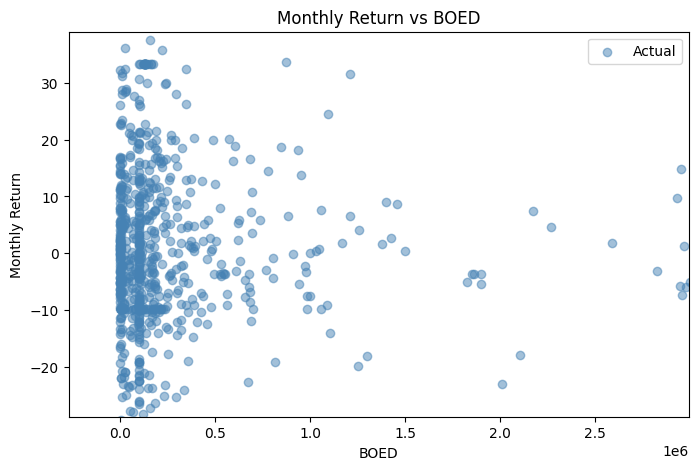

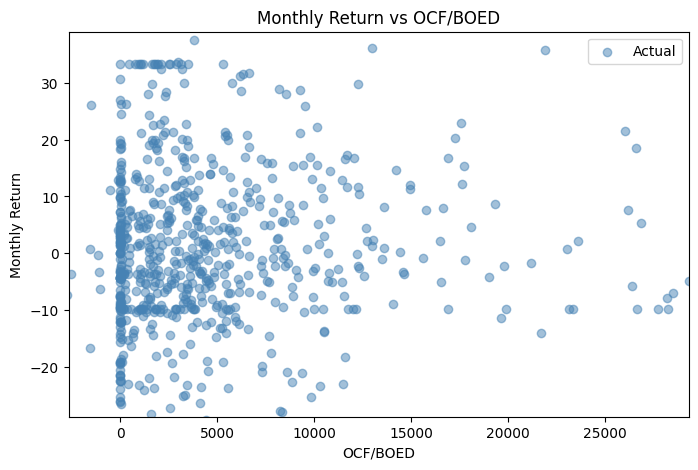

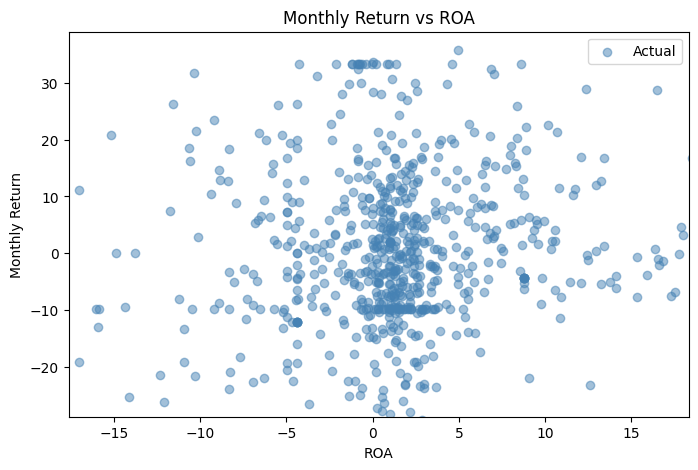

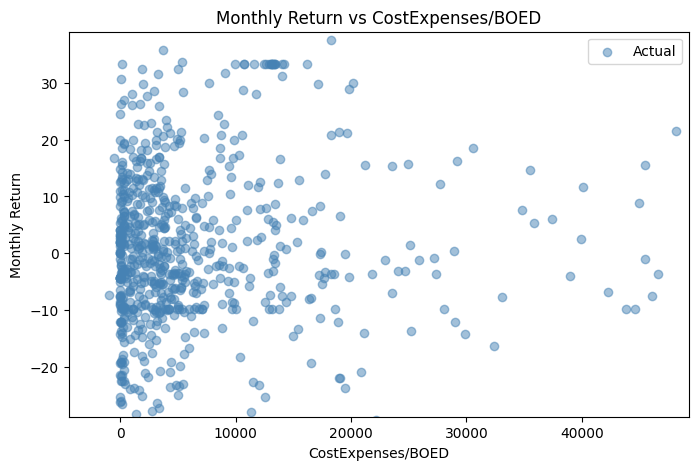

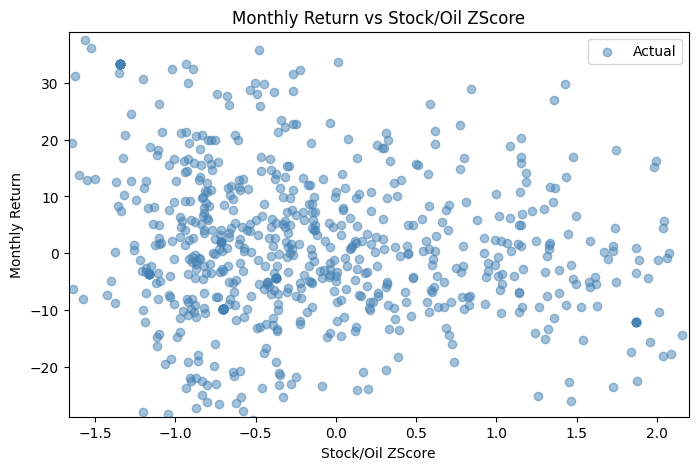

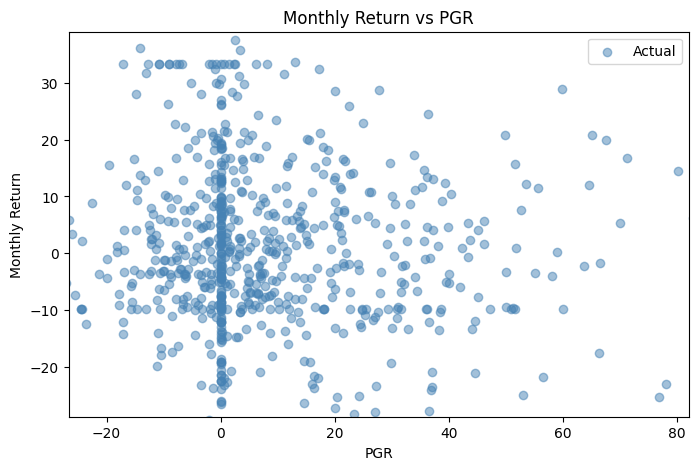

In [17]:
for col in X.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    
    ax.scatter(X[col], y, alpha=0.5, color='steelblue', label='Actual')
    
    # Use percentiles to ignore outliers
    x_low, x_high = X[col].quantile(0.05), X[col].quantile(0.95)
    y_low, y_high = y.quantile(0.05).item(), y.quantile(0.95).item()
    
    x_pad = (x_high - x_low) * 0.1
    y_pad = (y_high - y_low) * 0.1
    
    ax.set_xlim(x_low - x_pad, x_high + x_pad)
    ax.set_ylim(y_low - y_pad, y_high + y_pad)
    
    ax.set_xlabel(col)
    ax.set_ylabel('Monthly Return')
    ax.set_title(f'Monthly Return vs {col}')
    ax.legend()
    plt.show()

In [18]:
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
model.coef_

array([[-3.47199879e-08,  3.70790841e-05, -2.04894230e-02,
        -3.06141098e-05, -3.70499540e+00, -1.71442256e-03]])

In [20]:
model = RandomForestRegressor(n_estimators=200, random_state=0)
model.fit(X_train,y_train)

c:\Users\20231351\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [21]:
preds = model.predict(X_test)

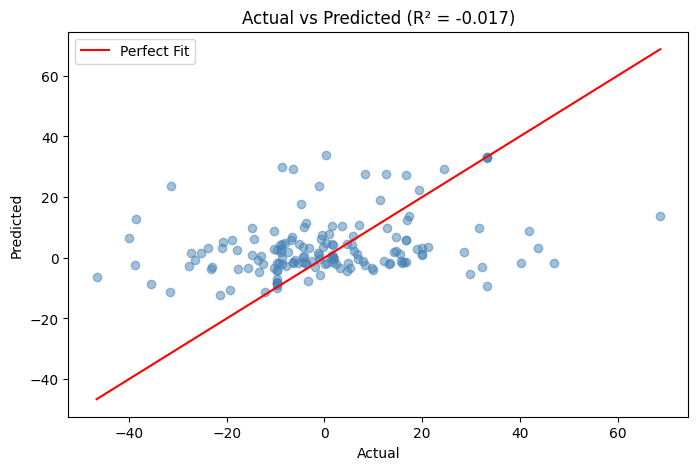

In [22]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, preds, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', label='Perfect Fit')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'Actual vs Predicted (R² = {r2_score(y_test, preds):.3f})')
plt.legend()
plt.show()

Successfully loaded 30 valid quarterly data points for CVX.

--- Step 1: Stationarity Check (ADF Test) ---
ADF Statistic: -5.4888
p-value: 0.0000
-> Based on p-value, setting ARIMA differencing parameter (d) to: 0

--- Step 2: ACF & PACF Plots ---


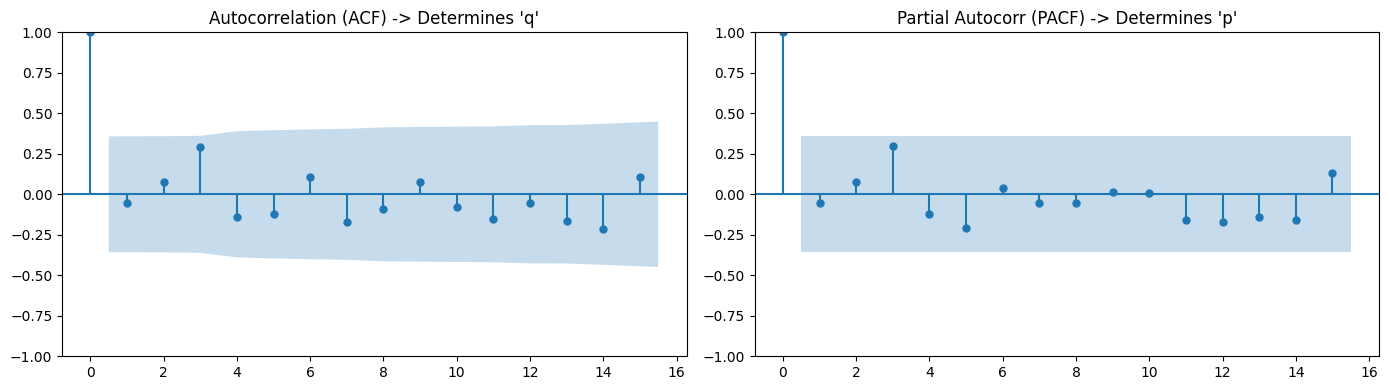


--- Step 3: Fitting ARIMA Model ---
                               SARIMAX Results                                
Dep. Variable:         Monthly Return   No. Observations:                   30
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -111.236
Date:                Tue, 17 Mar 2026   AIC                            230.471
Time:                        12:02:41   BIC                            236.076
Sample:                    06-30-2018   HQIC                           232.264
                         - 09-30-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.8641      1.983      0.940      0.347      -2.023       5.751
ar.L1         -0.1649      5.955     -0.028      0.978     -11.837      11.507
ma.L1          

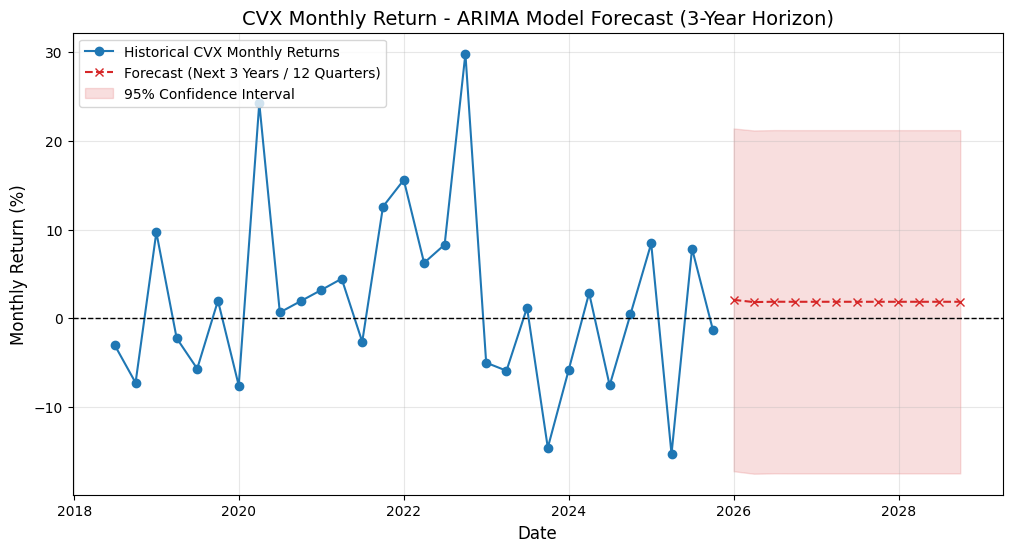

In [17]:
# Suppress warnings to keep your notebook output clean
warnings.filterwarnings("ignore")

# Ensure matplotlib plots render inline in the notebook
%matplotlib inline

# ==========================================
# 1. Load Data & Extract CVX
# ==========================================
# Using the exact absolute path you provided
cvx_data = oil_industry_data.get("CVX", {})
records = []

# Parse dates and Monthly Return, skipping nulls
for date_str, metrics in cvx_data.items():
    if metrics is not None and "Monthly Return" in metrics:
        records.append({
            "Date": pd.to_datetime(date_str),
            "Monthly Return": metrics["Monthly Return"]
        })

if not records:
    raise ValueError("No valid data found for CVX.")

# Create DataFrame, set Date as index, sort chronologically
df = pd.DataFrame(records).set_index("Date").sort_index()

# Resample to Quarterly frequency to ensure an even time-series
df = df.resample('Q').mean().interpolate()
ts_data = df["Monthly Return"]

print(f"Successfully loaded {len(ts_data)} valid quarterly data points for CVX.")

# ==========================================
# 2. Stationarity Check (ADF Test)
# ==========================================
print("\n--- Step 1: Stationarity Check (ADF Test) ---")
adf_result = adfuller(ts_data)
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")

# Determine differencing parameter (d)
d_val = 0 if adf_result[1] < 0.05 else 1
print(f"-> Based on p-value, setting ARIMA differencing parameter (d) to: {d_val}")

# ==========================================
# 3. Autocorrelation Plots (ACF & PACF)
# ==========================================
print("\n--- Step 2: ACF & PACF Plots ---")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts_data, ax=axes[0], title="Autocorrelation (ACF) -> Determines 'q'")
plot_pacf(ts_data, ax=axes[1], title="Partial Autocorr (PACF) -> Determines 'p'")
plt.tight_layout()
plt.show() 

# ==========================================
# 4. Fit the ARIMA Model
# ==========================================
print("\n--- Step 3: Fitting ARIMA Model ---")
p, q = 1, 1 
model = ARIMA(ts_data, order=(p, d_val, q))
fitted_model = model.fit()

print(fitted_model.summary())

# ==========================================
# 5. Forecasting & Visualization (3 YEARS AHEAD)
# ==========================================
print("\n--- Step 4: Forecasting ---")
# Forecast the next 12 periods (3 Years, since data is quarterly)
forecast_steps = 12
forecast = fitted_model.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

plt.figure(figsize=(12, 6))
plt.plot(ts_data.index, ts_data, label="Historical CVX Monthly Returns", color="#1f77b4", marker="o")
plt.plot(forecast_mean.index, forecast_mean, label="Forecast (Next 3 Years / 12 Quarters)", color="#d62728", linestyle="--", marker="x")

plt.fill_between(conf_int.index, 
                 conf_int.iloc[:, 0], 
                 conf_int.iloc[:, 1], 
                 color="#d62728", alpha=0.15, label="95% Confidence Interval")

plt.title("CVX Monthly Return - ARIMA Model Forecast (3-Year Horizon)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Monthly Return (%)", fontsize=12)
plt.axhline(0, color="black", linewidth=1, linestyle="--")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.show()

Loaded 30 quarterly records for CVX.
Features available: BOED, OCF/BOED, ROA, CostExpenses/BOED, Stock/Oil ZScore, PGR, Monthly Return

--- Step 1: Data Preparation ---
Aligned data: 29 matching rows ready for training.

--- Step 2: Fitting SARIMAX Model ---
                               SARIMAX Results                                
Dep. Variable:         Monthly Return   No. Observations:                   29
Model:               SARIMAX(1, 0, 1)   Log Likelihood                 -96.135
Date:                Tue, 17 Mar 2026   AIC                            210.269
Time:                        12:04:47   BIC                            221.932
Sample:                    09-30-2018   HQIC                           213.737
                         - 09-30-2025                                         
Covariance Type:                  opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------

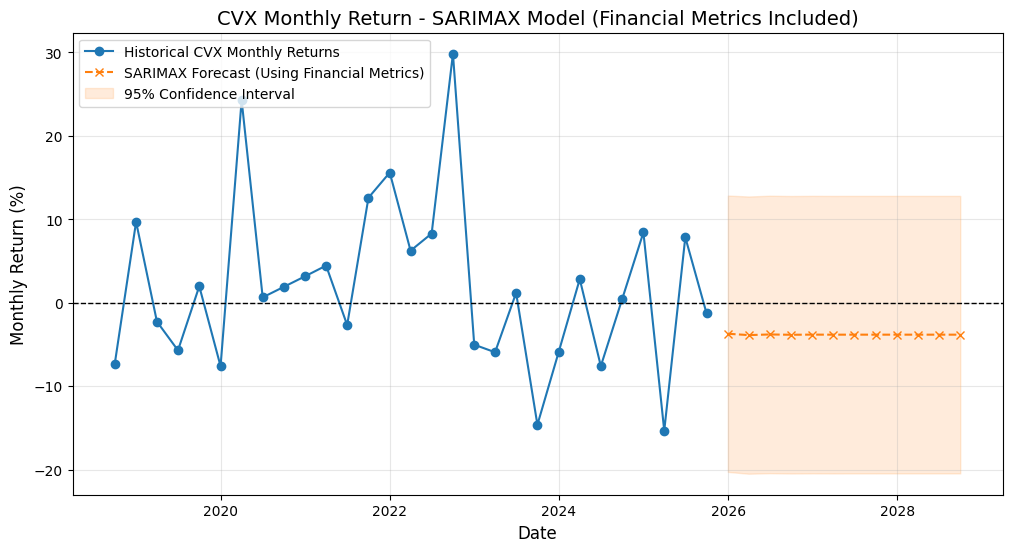

In [19]:
# Suppress warnings to keep your notebook output clean
warnings.filterwarnings("ignore")
%matplotlib inline

# ==========================================
# 1. Load Data & Extract CVX
# ==========================================
cvx_data = oil_industry_data.get("CVX", {})

# Convert the nested dictionary directly into a Pandas DataFrame
df = pd.DataFrame.from_dict(cvx_data, orient='index')
df.index = pd.to_datetime(df.index)

# Sort chronologically and resample to Quarterly
df = df.sort_index().resample('Q').mean()

# Drop any columns that are 100% empty, then interpolate missing values
df = df.dropna(axis=1, how='all')
df = df.interpolate(method='linear', limit_direction='both')

print(f"Loaded {len(df)} quarterly records for CVX.")
print(f"Features available: {', '.join(df.columns)}")

# ==========================================
# 2. Prepare Target (y) and Exogenous Variables (X)
# ==========================================
target_col = "Monthly Return"

# The target variable (endog)
y = df[target_col]

# The financial metrics (exog) - Everything EXCEPT the target column
X = df.drop(columns=[target_col])

print("\n--- Step 1: Data Preparation ---")
# CRUCIAL STEP: Lag the exogenous variables by 1 quarter. 
X_lagged = X.shift(1)

# FIX: Combine them temporarily to perfectly align dates and drop the NaNs created by the shift
aligned_df = pd.concat([y, X_lagged], axis=1).dropna()

# Split them back up safely
y_aligned = aligned_df[target_col]
X_lagged_aligned = aligned_df.drop(columns=[target_col])

print(f"Aligned data: {len(y_aligned)} matching rows ready for training.")

# ==========================================
# 3. Fit the SARIMAX Model
# ==========================================
print("\n--- Step 2: Fitting SARIMAX Model ---")

# Fit using the perfectly aligned datasets
model = SARIMAX(endog=y_aligned, 
                exog=X_lagged_aligned, 
                order=(1, 0, 1), 
                enforce_stationarity=False, 
                enforce_invertibility=False)

fitted_model = model.fit(disp=False)
print(fitted_model.summary())

# ==========================================
# 4. Forecasting (3 Years Ahead)
# ==========================================
print("\n--- Step 3: Forecasting 3 Years Ahead ---")
forecast_steps = 12

# To forecast the future, SARIMAX needs future Exogenous variables.
# We will assume CVX's financials remain exactly the same as the most recent quarter.
last_known_financials = X_lagged_aligned.iloc[-1:] 
future_X = pd.concat([last_known_financials] * forecast_steps, ignore_index=True)

# Generate the forecast
forecast = fitted_model.get_forecast(steps=forecast_steps, exog=future_X)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Create future dates for plotting
future_dates = pd.date_range(start=y_aligned.index[-1], periods=forecast_steps + 1, freq='Q')[1:]
forecast_mean.index = future_dates
conf_int.index = future_dates

# ==========================================
# 5. Visualization
# ==========================================
plt.figure(figsize=(12, 6))

# Plot Historical
plt.plot(y_aligned.index, y_aligned, label="Historical CVX Monthly Returns", color="#1f77b4", marker="o")

# Plot Forecast
plt.plot(forecast_mean.index, forecast_mean, label="SARIMAX Forecast (Using Financial Metrics)", color="#ff7f0e", linestyle="--", marker="x")

# Shade Confidence Interval
plt.fill_between(conf_int.index, 
                 conf_int.iloc[:, 0], 
                 conf_int.iloc[:, 1], 
                 color="#ff7f0e", alpha=0.15, label="95% Confidence Interval")

plt.title("CVX Monthly Return - SARIMAX Model (Financial Metrics Included)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Monthly Return (%)", fontsize=12)
plt.axhline(0, color="black", linewidth=1, linestyle="--")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.show()